# 01 - Exploratory Data Analysis

Tujuan notebook ini:
1. Memahami struktur dan ukuran data
2. Mengukur tingkat *class imbalance* pada target
3. Mengidentifikasi pola missing value (termasuk yang berpotensi informatif)
4. Eksplorasi awal hubungan fitur kunci terhadap target

Insight dari notebook ini akan menjadi dasar keputusan feature engineering di `02_feature_engineering.ipynb`.


In [1]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data import load_raw_tables, build_master_table
from src.config import TARGET_COL, ID_COL

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 100)


## 1. Load Data

In [2]:
tables = load_raw_tables()
df = build_master_table(tables)
print(f"Shape master table: {df.shape}")
df.head()

Path: D:\credit-risk-scorecard\data\raw\application_train.csv
[INFO] Loaded application_train: (307511, 122)
Path: D:\credit-risk-scorecard\data\raw\application_test.csv
[INFO] Loaded application_test: (48744, 121)
Path: D:\credit-risk-scorecard\data\raw\bureau.csv
[INFO] Loaded bureau: (1716428, 17)
Path: D:\credit-risk-scorecard\data\raw\bureau_balance.csv
[INFO] Loaded bureau_balance: (27299925, 3)
Path: D:\credit-risk-scorecard\data\raw\previous_application.csv
[INFO] Loaded previous_application: (1670214, 37)
Path: D:\credit-risk-scorecard\data\raw\installments_payments.csv
[INFO] Loaded installments_payments: (13605401, 8)
Path: D:\credit-risk-scorecard\data\raw\credit_card_balance.csv
[INFO] Loaded credit_card_balance: (3840312, 23)
Path: D:\credit-risk-scorecard\data\raw\POS_CASH_balance.csv
[INFO] Loaded pos_cash_balance: (10001358, 8)
[INFO] Setelah merge bureau: (307511, 127)
[INFO] Setelah merge previous_application: (307511, 131)
Shape master table: (307511, 131)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,...,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,bureau_credit_count,bureau_amt_credit_sum_mean,bureau_amt_credit_sum_max,bureau_credit_day_overdue_mean,bureau_credit_day_overdue_max,prev_application_count,prev_amt_credit_mean,prev_amt_annuity_mean,prev_days_decision_mean
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,...,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0,8.0,108131.945625,450000.0,0.0,0.0,1.0,179055.00,9251.775,-606.000000
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,...,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,254350.125000,810000.0,0.0,0.0,3.0,484191.00,56553.990,-1305.000000
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,-815.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,94518.900000,94537.8,0.0,0.0,1.0,20106.00,5357.250,-815.000000
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,297000.0,Unaccompanied,Working,Secondary / secondary special,Civil marriage,House / apartment,0.008019,-19005,-3039,-9833.0,-2437,NaN,1,1,0,1,0,0,Laborers,2.0,2,2,WEDNESDAY,17,0,0,0,0,0,0,Business Entity Type 3,NaN,0.650442,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.0,2.0,0.0,-617.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.0,291695.50,23651.17

## 2. Distribusi Target

Ini langkah pertama yang krusial: mengukur seberapa imbalance target-nya.
Rasio imbalance ini akan menentukan strategi modeling di tahap selanjutnya
(class weighting, threshold tuning, pemilihan metric evaluasi).

Jumlah per kelas:
TARGET
0    282686
1     24825
Name: count, dtype: int64

Persentase per kelas:
TARGET
0    91.93
1     8.07
Name: proportion, dtype: float64


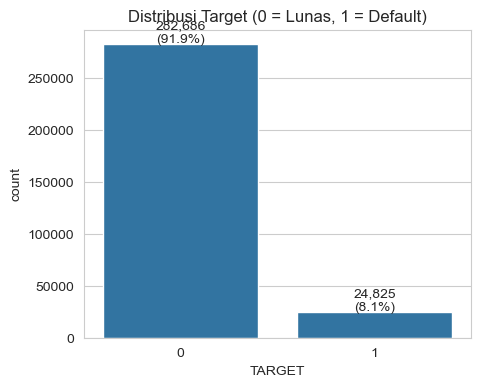

In [3]:
target_counts = df[TARGET_COL].value_counts()
target_pct = df[TARGET_COL].value_counts(normalize=True) * 100

print("Jumlah per kelas:")
print(target_counts)
print("\nPersentase per kelas:")
print(target_pct.round(2))

fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(x=TARGET_COL, data=df, ax=ax)
ax.set_title("Distribusi Target (0 = Lunas, 1 = Default)")
for i, v in enumerate(target_counts):
    ax.text(i, v + 2000, f"{v:,}\n({target_pct.iloc[i]:.1f}%)", ha="center")
plt.show()

**Insight:** Target sangat imbalanced — nasabah ***default*** (`TARGET=1`) hanya
sekitar 8% dari total data, sementara 92% adalah nasabah yang melunasi
pinjamannya. Implikasinya untuk tahap modeling:

- **Accuracy bukan metric yang representatif** — model yang selalu
  memprediksi "tidak default" akan tetap mendapat accuracy ~92% tanpa
  benar-benar berguna. Evaluasi akan difokuskan pada AUC, Gini, dan KS
  statistic (lihat `src/evaluation.py`).
- Strategi penanganan imbalance perlu dipertimbangkan di tahap modeling,
  baik lewat `class_weight="balanced"` (Logistic Regression) maupun
  `scale_pos_weight` (LightGBM).

***Apa itu nasabah "default"?***

Default dalam konteks kredit/pinjaman artinya gagal bayar — nasabah tidak mampu melunasi kewajiban pinjamannya sesuai perjanjian (telat bayar dalam jangka waktu signifikan, atau tidak membayar sama sekali).

## 3. Analisis Missing Value

Di dataset credit scoring, missing value sering **informatif**, bukan sekadar
noise. Contoh: nasabah tanpa riwayat di tabel bureau bisa berarti "thin file"
(belum punya riwayat kredit), bukan data yang hilang secara acak.

In [4]:
missing = df.isnull().mean().sort_values(ascending=False) * 100
missing = missing[missing > 0]

print(f"Jumlah kolom dengan missing value: {len(missing)} dari {df.shape[1]} kolom")
missing.head(20)

Jumlah kolom dengan missing value: 76 dari 131 kolom


COMMONAREA_MEDI             69.872297
COMMONAREA_AVG              69.872297
COMMONAREA_MODE             69.872297
NONLIVINGAPARTMENTS_MODE    69.432963
NONLIVINGAPARTMENTS_MEDI    69.432963
NONLIVINGAPARTMENTS_AVG     69.432963
FONDKAPREMONT_MODE          68.386172
LIVINGAPARTMENTS_MODE       68.354953
LIVINGAPARTMENTS_MEDI       68.354953
LIVINGAPARTMENTS_AVG        68.354953
FLOORSMIN_MODE              67.848630
FLOORSMIN_AVG               67.848630
FLOORSMIN_MEDI              67.848630
YEARS_BUILD_AVG             66.497784
YEARS_BUILD_MEDI            66.497784
YEARS_BUILD_MODE            66.497784
OWN_CAR_AGE                 65.990810
LANDAREA_MEDI               59.376738
LANDAREA_AVG                59.376738
LANDAREA_MODE               59.376738
dtype: float64

In [8]:
# Cek kolom COMMONAREA_MEDI secara spesifik
print(df["COMMONAREA_MEDI"].isnull().sum())   # jumlah baris yang benar-benar NaN
print((df["COMMONAREA_MEDI"] == 0).sum())     # jumlah baris yang nilainya literal 0
print(df["COMMONAREA_MEDI"].describe())       # lihat count, mean, min, max

214865
8691
count    92646.000000
mean         0.044595
std          0.076144
min          0.000000
25%          0.007900
50%          0.020800
75%          0.051300
max          1.000000
Name: COMMONAREA_MEDI, dtype: float64


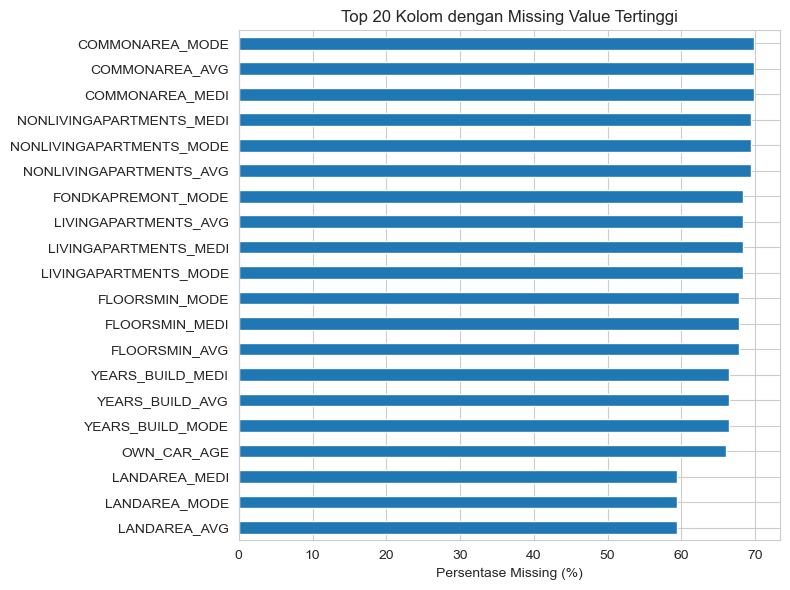

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))
missing.head(20).sort_values().plot(kind="barh", ax=ax)
ax.set_xlabel("Persentase Missing (%)")
ax.set_title("Top 20 Kolom dengan Missing Value Tertinggi")
plt.tight_layout()
plt.show()

**Insight:** 76 dari 131 kolom (58%) memiliki missing value, dengan 20
kolom teratas didominasi oleh atribut terkait **properti tempat tinggal**
(`COMMONAREA_*`, `LIVINGAPARTMENTS_*`, `YEARS_BUILD_*`, `OWN_CAR_AGE`),
dengan missing rate antara 60-70%.

Pengecekan lebih lanjut pada `COMMONAREA_MEDI` mengonfirmasi bahwa missing
value ini benar-benar NaN, bukan nilai 0 yang under-represented — dari
307.511 baris, 214.865 (69.9%) NaN, sementara dari yang terisi (92.646
baris), hanya 8.691 yang bernilai literal 0:

| Kategori | Jumlah baris |
|---|---|
| NaN (tidak ada data) | 214.865 |
| Bernilai 0 (common area memang 0%) | 8.691 |
| Bernilai > 0 | 83.955 |

Ini mengindikasikan dua kemungkinan yang berbeda maknanya:
1. **NaN** → informasi properti memang tidak tersedia/tidak diisi
   (kemungkinan jenis hunian tidak relevan dengan konsep "common area",
   misal rumah tapak)
2. **0** → common area memang benar-benar tidak ada, dan ini adalah nilai
   yang valid, bukan data hilang

Karena NaN dan 0 punya makna berbeda di kolom-kolom properti ini,
strategi imputasi sederhana seperti `fillna(0)` berisiko mencampur dua
kategori yang sebenarnya berbeda. Pendekatan yang lebih tepat adalah
menambahkan flag missing terpisah (`*_MISSING`) sebelum imputasi —
pola serupa yang sudah diterapkan pada `DAYS_EMPLOYED` di
`src/features.py::add_employment_features()`.

## 4. Eksplorasi Fitur Kunci vs Target

Mengecek beberapa fitur yang secara domain knowledge relevan: income,
credit amount, usia, dan lama bekerja.

- AMT_INCOME_TOTAL (total income nasabah) — logika: makin tinggi income, makin mampu bayar
- AMT_CREDIT (jumlah pinjaman) — logika: pinjaman lebih besar = beban lebih berat
- AMT_ANNUITY (jumlah cicilan per periode) — logika: cicilan tinggi relatif ke kemampuan bayar = risiko lebih tinggi
- DAYS_BIRTH (usia, dalam hari negatif) — logika: usia berkorelasi dengan stabilitas finansial/karier

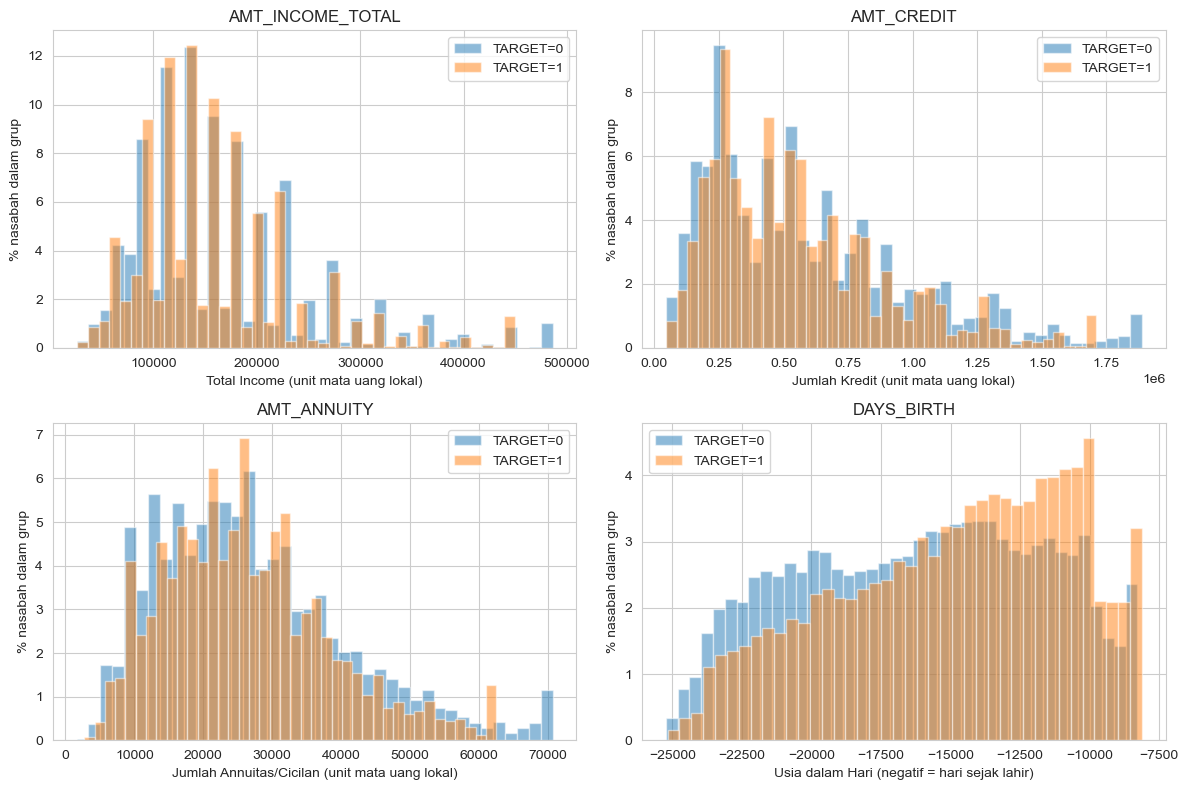

In [6]:
key_features = ["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY", "DAYS_BIRTH"]
x_labels = {
    "AMT_INCOME_TOTAL": "Total Income (unit mata uang lokal)",
    "AMT_CREDIT": "Jumlah Kredit (unit mata uang lokal)",
    "AMT_ANNUITY": "Jumlah Annuitas/Cicilan (unit mata uang lokal)",
    "DAYS_BIRTH": "Usia dalam Hari (negatif = hari sejak lahir)",
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), key_features):
    for target_val in [0, 1]:
        subset = df[df[TARGET_COL] == target_val][col].dropna()
        subset_clipped = subset.clip(upper=subset.quantile(0.99))
        weights = np.ones_like(subset_clipped) / len(subset_clipped) * 100
        ax.hist(subset_clipped, bins=40, weights=weights, alpha=0.5, label=f"TARGET={target_val}")
    ax.set_title(col)
    ax.set_xlabel(x_labels[col])
    ax.set_ylabel("% nasabah dalam grup")
    ax.legend()
plt.tight_layout()
plt.show()

**Insight:** Dari empat fitur yang dieksplorasi, hanya **usia (`DAYS_BIRTH`)**
yang menunjukkan separasi visual jelas antara nasabah default vs lunas —
nasabah default cenderung lebih muda, terlihat dari distribusi `TARGET=1`
yang bergeser ke arah usia lebih muda dibanding `TARGET=0`. Ini konsisten
dengan intuisi bisnis: nasabah yang lebih muda umumnya memiliki histori
kredit yang lebih singkat dan stabilitas finansial/karier yang belum
seterbangun nasabah yang lebih tua.

Sebaliknya, `AMT_INCOME_TOTAL` dan `AMT_CREDIT` menunjukkan distribusi
yang **hampir identik** antara kedua kelas target — secara univariate,
income dan jumlah pinjaman saja tidak cukup memisahkan nasabah berisiko
dari yang tidak. Ini mengindikasikan bahwa risiko default kemungkinan
lebih dipengaruhi oleh **rasio antar variabel** (misal beban cicilan
relatif terhadap income) daripada nilai absolut satu variabel saja —
inilah motivasi utama dibuatnya fitur rasio (`DEBT_TO_INCOME_RATIO`,
`ANNUITY_TO_INCOME_RATIO`) di `src/features.py`.

`AMT_ANNUITY` menunjukkan perbedaan tipis namun konsisten dengan pola
ini: nasabah default sedikit terkonsentrasi di cicilan menengah, bukan
ekstrem tinggi — mendukung hipotesis bahwa **beban relatif**, bukan
nominal cicilan itu sendiri, yang lebih menentukan.

## 5. Ringkasan & Langkah Selanjutnya